# Notebook 32 - Final MATLAB parity gate

Goal: compare the current Python UltraTimTrack-compatible final output against MATLAB `Fdat.Region.ANG`, `Fdat.Region.PEN`, and `Fdat.Region.FL`.

This notebook deliberately excludes:

- speckle-adaptive Kalman
- local mechanics / strain maps
- new smoothing experiments
- old selected-line debug values

The purpose is to decide whether the current Python baseline is close enough to MATLAB before adding new project variants.

In [1]:
from pathlib import Path
import sys
import os
import json

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import cv2
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

current = Path.cwd()
if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ultrasound_tracker.roi import load_rois

plt.style.use("default")
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


## 1. Paths and acceptance thresholds

The main alignment uses `PRIMARY_PY_OFFSET = 1` because MATLAB `Fdat.Region.Time[0]` starts at about one frame period, while the Python result has frame 0. The notebook still tests neighboring offsets so this assumption is visible.

In [2]:
VIDEO_NAME = "Test2"
MATLAB_MAT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
PY_NPZ = PROJECT_ROOT / "results" / f"{VIDEO_NAME}_timtrack_final_features_arrays.npz"
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / f"{VIDEO_NAME}.mp4"
ROI_JSON = PROJECT_ROOT / "data" / "rois" / f"{VIDEO_NAME}_rois.json"

OUT_DIR = PROJECT_ROOT / "results" / "matlab_parity_gate"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_PY_OFFSET = 1
BASELINE_SECONDS = 2.0
MATLAB_COORDINATE_BASE = 1.0

# Practical thresholds for this current validation case.
# Strict parity would be lower, but ROI mismatch makes FL especially sensitive.
WORKING_THRESHOLDS = {
    "ANG_deg": 3.0,
    "PEN_deg": 3.0,
    "FL_mm": 7.0,
}
STRICT_THRESHOLDS = {
    "ANG_deg": 2.0,
    "PEN_deg": 2.0,
    "FL_mm": 5.0,
}

for label, path in [
    ("MATLAB_MAT", MATLAB_MAT),
    ("PY_NPZ", PY_NPZ),
    ("VIDEO_PATH", VIDEO_PATH),
    ("ROI_JSON", ROI_JSON),
    ("OUT_DIR", OUT_DIR),
]:
    print(label, path, "exists=", path.exists())

MATLAB_MAT /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat exists= True
PY_NPZ /Users/grosbedou/PycharmProjects/NDORMS/results/Test2_timtrack_final_features_arrays.npz exists= True
VIDEO_PATH /Users/grosbedou/PycharmProjects/NDORMS/data/raw/Test2.mp4 exists= True
ROI_JSON /Users/grosbedou/PycharmProjects/NDORMS/data/rois/Test2_rois.json exists= True
OUT_DIR /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate exists= True


## 2. Load MATLAB `Fdat` and saved MATLAB ROI geometry

`TrackingData.S` and `TrackingData.D` are present in the `.mat` file, but Python sees them as MATLAB MCOS `images.roi.Rectangle` objects, so the `.Position` property is not directly decoded by `scipy.io.loadmat`.

The useful geometry is still available through `Fdat.Region`:

- `sup_x`, `sup_y`
- `deep_x`, `deep_y`
- `ROIx`, `ROIy`

Those are the MATLAB geometry references used in this notebook.

In [3]:
mat = sio.loadmat(MATLAB_MAT, squeeze_me=False, struct_as_record=False)
print("MATLAB keys:", [k for k in mat.keys() if not k.startswith("__")])

Fdat = mat["Fdat"].item()
TrackingData = mat["TrackingData"].item() if "TrackingData" in mat else None
Region = Fdat.Region.item()


def mat1d(x, dtype=float):
    return np.asarray(x, dtype=dtype).ravel()

matlab = {
    "ANG_deg": mat1d(Region.ANG),
    "PEN_deg": mat1d(Region.PEN),
    "FL_mm": mat1d(Region.FL),
    "Time": mat1d(Region.Time),
}

matlab_roi = {
    "ROIx": mat1d(Region.ROIx[0, 0]),
    "ROIy": mat1d(Region.ROIy[0, 0]),
    "sup_x": mat1d(Region.sup_x[0, 0]),
    "sup_y": mat1d(Region.sup_y[0, 0]),
    "deep_x": mat1d(Region.deep_x[0, 0]),
    "deep_y": mat1d(Region.deep_y[0, 0]),
}

mcos_info = []
if TrackingData is not None:
    for name in ["S", "D"]:
        if hasattr(TrackingData, name):
            obj = getattr(TrackingData, name)
            cls = obj["s2"][0] if getattr(obj, "dtype", None) is not None and obj.dtype.names else "unknown"
            mcos_info.append({"name": name, "present": True, "python_visible_class": cls})
        else:
            mcos_info.append({"name": name, "present": False, "python_visible_class": None})

print("MATLAB sample count:", len(matlab["ANG_deg"]))
print("MATLAB Time first/last:", matlab["Time"][0], matlab["Time"][-1])
print("Fdat.R:", np.asarray(Fdat.R).ravel())
print("TrackingData S/D visible status:")
display(pd.DataFrame(mcos_info))
print("MATLAB ROI first frame:")
for k, v in matlab_roi.items():
    print(k, v)

MATLAB keys: ['TrackingData', 'Fdat']
MATLAB sample count: 2666
MATLAB Time first/last: 0.029993091648583443 79.96158233512347
Fdat.R: [3.05529211 2.33582603 0.77069289 0.47921255 0.47921255]
TrackingData S/D visible status:


,name,present,python_visible_class
0,S,True,b'images.roi.Rectangle'
1,D,True,b'images.roi.Rectangle'


MATLAB ROI first frame:
ROIx [  1.   1. 706. 706.   1.]
ROIy [ 36.85315315 309.92612613 332.90647011  53.77084357  36.85315315]
sup_x [  1. 706.]
sup_y [36.85315315 53.77084357]
deep_x [  1. 706.]
deep_y [309.92612613 332.90647011]


## 3. Load current Python final outputs

This uses the current package-generated final outputs. The old selected segment is intentionally ignored.

In [4]:
py_data = np.load(PY_NPZ, allow_pickle=True)
rois = load_rois(ROI_JSON)

python = {
    "frame": np.asarray(py_data["frame"], dtype=int),
    "time_s": np.asarray(py_data["time_s"], dtype=float) if "time_s" in py_data.files else np.asarray(py_data["frame"], dtype=float),
    "ANG_deg": np.asarray(py_data["ANG_deg"], dtype=float),
    "PEN_deg": np.asarray(py_data["PEN_deg"], dtype=float),
    "FL_mm": np.asarray(py_data["FL_mm"], dtype=float),
}

print("Python sample count:", len(python["frame"]))
print("Python frame first/last:", python["frame"][0], python["frame"][-1])
print("Python time first/last:", python["time_s"][0], python["time_s"][-1])
print("Python ROI JSON:")
print(json.dumps(rois, indent=2))
print("Python keys used: ANG_deg, PEN_deg, FL_mm")

Python sample count: 2667
Python frame first/last: 0 2666
Python time first/last: 0.0 79.96160888671875
Python ROI JSON:
{
  "superficial": [
    16,
    23,
    685,
    36
  ],
  "deep": [
    21,
    298,
    683,
    69
  ],
  "fascicle": [
    21,
    70,
    681,
    221
  ]
}
Python keys used: ANG_deg, PEN_deg, FL_mm


## 4. Alignment check

Offset meaning:

```text
offset = 0 -> Python[0] compared with MATLAB[0]
offset = 1 -> Python[1] compared with MATLAB[0]
offset = -1 -> Python[0] compared with MATLAB[1]
```

The main gate uses `PRIMARY_PY_OFFSET`, but the offset table tells us whether a one-frame shift changes the conclusion.

In [5]:
SIGNALS = ["ANG_deg", "PEN_deg", "FL_mm"]


def align_with_offset(offset):
    out = {}
    if offset >= 0:
        py_start = int(offset)
        mat_start = 0
    else:
        py_start = 0
        mat_start = int(-offset)
    n = min(len(python["frame"]) - py_start, len(matlab["ANG_deg"]) - mat_start)
    if n <= 0:
        raise ValueError(f"No overlap for offset {offset}")
    out["frame"] = python["frame"][py_start : py_start + n]
    out["python_time_s"] = python["time_s"][py_start : py_start + n]
    out["matlab_time_s"] = matlab["Time"][mat_start : mat_start + n]
    out["py_start"] = py_start
    out["mat_start"] = mat_start
    out["n"] = n
    for sig in SIGNALS:
        out[f"py_{sig}"] = python[sig][py_start : py_start + n]
        out[f"mat_{sig}"] = matlab[sig][mat_start : mat_start + n]
    return out


def finite_pair(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    return a[mask], b[mask], mask


def med_abs_error(a, b):
    aa, bb, _ = finite_pair(a, b)
    if len(aa) == 0:
        return np.nan
    return float(np.nanmedian(np.abs(aa - bb)))

rows = []
for offset in range(-5, 6):
    aligned = align_with_offset(offset)
    row = {"offset": offset, "n": aligned["n"], "py_start": aligned["py_start"], "mat_start": aligned["mat_start"]}
    for sig in SIGNALS:
        row[f"{sig}_median_abs_error"] = med_abs_error(aligned[f"py_{sig}"], aligned[f"mat_{sig}"])
    row["combined_display_score"] = row["ANG_deg_median_abs_error"] + row["PEN_deg_median_abs_error"] + row["FL_mm_median_abs_error"] / 3.0
    rows.append(row)

offset_df = pd.DataFrame(rows)
offset_csv = OUT_DIR / "notebook32_offset_sensitivity.csv"
offset_df.to_csv(offset_csv, index=False)
print("Saved:", offset_csv)
display(offset_df)

aligned = align_with_offset(PRIMARY_PY_OFFSET)
print("Primary offset:", PRIMARY_PY_OFFSET)
print("py_start:", aligned["py_start"], "mat_start:", aligned["mat_start"], "n:", aligned["n"])

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_offset_sensitivity.csv


,offset,n,py_start,mat_start,ANG_deg_median_abs_error,PEN_deg_median_abs_error,FL_mm_median_abs_error,combined_display_score
0,-5,2661,0,5,2.715017,2.478429,6.900704,7.493681
1,-4,2662,0,4,2.715412,2.476028,6.873524,7.482615
2,-3,2663,0,3,2.726643,2.463616,6.901403,7.490726
3,-2,2664,0,2,2.723678,2.462754,6.902264,7.487186
4,-1,2665,0,1,2.720278,2.466671,6.899344,7.486730
5,0,2666,0,0,2.748270,2.467667,6.870554,7.506122
6,1,2666,1,0,2.749504,2.469168,6.928372,7.528130
7,2,2665,2,0,2.759577,2.461902,6.939390,7.534609
8,3,2664,3,0,2.758655,2.460397,6.903892,7.520349
9,4,2663,4,0,2.748856,2.453608,6.898153,7.501848


Primary offset: 1
py_start: 1 mat_start: 0 n: 2666


## 5. Metrics: absolute, baseline-normalized, and windows

Absolute values are sensitive to ROI differences. Baseline-normalized values ask a different question: does Python reproduce the same change over time as MATLAB?

In [6]:
def metric_row(signal, py, mat, domain, window_name, threshold=None):
    py_f, mat_f, mask = finite_pair(py, mat)
    if len(py_f) == 0:
        return {
            "signal": signal,
            "domain": domain,
            "window": window_name,
            "n": 0,
            "bias_median_py_minus_mat": np.nan,
            "mae": np.nan,
            "median_abs_error": np.nan,
            "rmse": np.nan,
            "q95_abs_error": np.nan,
            "corr": np.nan,
            "working_threshold": threshold,
            "working_gate": "no data",
        }
    diff = py_f - mat_f
    corr = np.corrcoef(py_f, mat_f)[0, 1] if len(py_f) > 2 and np.nanstd(py_f) > 0 and np.nanstd(mat_f) > 0 else np.nan
    medae = float(np.nanmedian(np.abs(diff)))
    if threshold is None:
        gate = "not checked"
    elif medae <= threshold:
        gate = "pass"
    else:
        gate = "review"
    return {
        "signal": signal,
        "domain": domain,
        "window": window_name,
        "n": int(len(py_f)),
        "bias_median_py_minus_mat": float(np.nanmedian(diff)),
        "mae": float(np.nanmean(np.abs(diff))),
        "median_abs_error": medae,
        "rmse": float(np.sqrt(np.nanmean(diff ** 2))),
        "q95_abs_error": float(np.nanpercentile(np.abs(diff), 95)),
        "corr": float(corr) if np.isfinite(corr) else np.nan,
        "working_threshold": threshold,
        "strict_threshold": STRICT_THRESHOLDS.get(signal),
        "working_gate": gate,
        "strict_gate": "pass" if signal in STRICT_THRESHOLDS and medae <= STRICT_THRESHOLDS[signal] else "review",
    }

primary_time = aligned["python_time_s"]
baseline_mask = primary_time <= (primary_time[0] + BASELINE_SECONDS)
if baseline_mask.sum() < 10:
    baseline_mask[: min(60, len(primary_time))] = True

mat_fl = aligned["mat_FL_mm"]
mat_pen = aligned["mat_PEN_deg"]
contraction_mask = (mat_fl <= np.nanpercentile(mat_fl, 20)) | (mat_pen >= np.nanpercentile(mat_pen, 80))
rest_mask = baseline_mask.copy()
full_mask = np.ones(aligned["n"], dtype=bool)

windows = {
    "full": full_mask,
    "baseline_first_2s": rest_mask,
    "matlab_high_contraction": contraction_mask,
}

metrics = []
for sig in SIGNALS:
    threshold = WORKING_THRESHOLDS[sig]
    py = aligned[f"py_{sig}"]
    matv = aligned[f"mat_{sig}"]

    py_base = np.nanmedian(py[baseline_mask])
    mat_base = np.nanmedian(matv[baseline_mask])
    py_delta = py - py_base
    mat_delta = matv - mat_base

    for window_name, mask in windows.items():
        metrics.append(metric_row(sig, py[mask], matv[mask], "absolute", window_name, threshold))
        metrics.append(metric_row(sig, py_delta[mask], mat_delta[mask], "baseline_delta", window_name, threshold))

metrics_df = pd.DataFrame(metrics)
metrics_csv = OUT_DIR / "notebook32_matlab_parity_metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)
print("Saved:", metrics_csv)
display(metrics_df)

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_matlab_parity_metrics.csv


,signal,domain,window,n,bias_median_py_minus_mat,mae,median_abs_error,rmse,q95_abs_error,corr,working_threshold,strict_threshold,working_gate,strict_gate
0,ANG_deg,absolute,full,2664,-1.166522,3.119531,2.749504,3.849178,7.565046,0.639627,3.0,2.0,pass,review
1,ANG_deg,baseline_delta,full,2664,-2.651654,3.627723,2.651654,4.635412,9.050178,0.639627,3.0,2.0,pass,review
2,ANG_deg,absolute,baseline_first_2s,67,1.485132,1.530405,1.503846,1.640715,2.782488,0.289101,3.0,2.0,pass,pass
3,ANG_deg,baseline_delta,baseline_first_2s,67,0.000000,1.125700,0.029346,1.942975,4.267620,0.289101,3.0,2.0,pass,pass
4,ANG_deg,absolute,matlab_high_contraction,560,-1.966027,2.986395,2.010100,4.006952,8.080887,0.466880,3.0,2.0,pass,review
5,ANG_deg,baseline_delta,matlab_high_contraction,560,-3.451159,4.361803,3.451159,5.175554,9.566019,0.466880,3.0,2.0,review,review
6,PEN_deg,absolute,full,2664,-1.265419,3.002388,2.469168,3.738907,7.465412,0.629407,3.0,2.0,pass,review
7,PEN_deg,baseline_delta,full,2664,-2.191146,3.304812,2.393189,4.222588,8.391138,0.629407,3.0,2.0,pass,review
8,PEN_deg,absolute,baseline_first_2s,67,0.903072,1.083987,0.952499,1.203913,2.365894,0.288993,3.0,2.0,pass,pass
9,PEN_deg,baseline_delta,baseline_first_2s,67,-0.022654,0.785641,0.059900,1.404263,3.291621,0.288993,3.0,2.0,pass,pass


In [7]:
gate_summary = metrics_df[(metrics_df["domain"] == "absolute") & (metrics_df["window"] == "full")].copy()
gate_summary = gate_summary[[
    "signal",
    "n",
    "bias_median_py_minus_mat",
    "median_abs_error",
    "mae",
    "q95_abs_error",
    "corr",
    "working_threshold",
    "working_gate",
    "strict_threshold",
    "strict_gate",
]]
summary_csv = OUT_DIR / "notebook32_gate_summary.csv"
gate_summary.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)
display(gate_summary)

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_gate_summary.csv


,signal,n,bias_median_py_minus_mat,median_abs_error,mae,q95_abs_error,corr,working_threshold,working_gate,strict_threshold,strict_gate
0,ANG_deg,2664,-1.166522,2.749504,3.119531,7.565046,0.639627,3.0,pass,2.0,review
6,PEN_deg,2664,-1.265419,2.469168,3.002388,7.465412,0.629407,3.0,pass,2.0,review
12,FL_mm,2664,1.234784,6.928372,6.775572,14.215330,0.555634,7.0,pass,5.0,review


## 6. Save aligned arrays and worst-frame table

In [8]:
aligned_npz = OUT_DIR / "notebook32_aligned_python_vs_matlab_arrays.npz"
np.savez(
    aligned_npz,
    frame=aligned["frame"],
    python_time_s=aligned["python_time_s"],
    matlab_time_s=aligned["matlab_time_s"],
    py_ANG_deg=aligned["py_ANG_deg"],
    mat_ANG_deg=aligned["mat_ANG_deg"],
    py_PEN_deg=aligned["py_PEN_deg"],
    mat_PEN_deg=aligned["mat_PEN_deg"],
    py_FL_mm=aligned["py_FL_mm"],
    mat_FL_mm=aligned["mat_FL_mm"],
    primary_py_offset=np.array([PRIMARY_PY_OFFSET]),
)
print("Saved:", aligned_npz)

comparison = pd.DataFrame({
    "frame": aligned["frame"],
    "python_time_s": aligned["python_time_s"],
    "matlab_time_s": aligned["matlab_time_s"],
})
for sig in SIGNALS:
    comparison[f"py_{sig}"] = aligned[f"py_{sig}"]
    comparison[f"mat_{sig}"] = aligned[f"mat_{sig}"]
    comparison[f"diff_{sig}"] = aligned[f"py_{sig}"] - aligned[f"mat_{sig}"]
    comparison[f"abs_diff_{sig}"] = np.abs(comparison[f"diff_{sig}"])

comparison_csv = OUT_DIR / "notebook32_aligned_python_vs_matlab.csv"
comparison.to_csv(comparison_csv, index=False)
print("Saved:", comparison_csv)

worst_tables = []
for sig in SIGNALS:
    tmp = comparison.sort_values(f"abs_diff_{sig}", ascending=False).head(20).copy()
    tmp.insert(0, "ranked_signal", sig)
    worst_tables.append(tmp)
worst_df = pd.concat(worst_tables, ignore_index=True)
worst_csv = OUT_DIR / "notebook32_worst_frames.csv"
worst_df.to_csv(worst_csv, index=False)
print("Saved:", worst_csv)
display(worst_df[["ranked_signal", "frame", "python_time_s", f"py_ANG_deg", f"mat_ANG_deg", "diff_ANG_deg", "py_PEN_deg", "mat_PEN_deg", "diff_PEN_deg", "py_FL_mm", "mat_FL_mm", "diff_FL_mm"]].head(30))

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_aligned_python_vs_matlab_arrays.npz
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_aligned_python_vs_matlab.csv


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_worst_frames.csv


,ranked_signal,frame,python_time_s,py_ANG_deg,mat_ANG_deg,diff_ANG_deg,py_PEN_deg,mat_PEN_deg,diff_PEN_deg,py_FL_mm,mat_FL_mm,diff_FL_mm
0,ANG_deg,437,13.106985,17.0,29.030857,-12.030857,18.068369,29.876713,-11.808344,77.609406,47.114910,30.494496
1,ANG_deg,438,13.136978,17.0,28.881285,-11.881285,18.121813,29.747271,-11.625458,77.602463,47.196077,30.406386
2,ANG_deg,441,13.226958,17.0,28.772123,-11.772123,18.162041,29.638812,-11.476771,77.500183,47.540757,29.959426
3,ANG_deg,2503,75.072731,21.0,31.842515,-10.842515,22.688187,33.174065,-10.485878,63.022869,44.033850,18.989019
4,ANG_deg,1493,44.779701,21.0,31.368682,-10.368682,21.864246,32.256410,-10.392163,64.651497,44.799842,19.851655
5,ANG_deg,2566,76.962296,21.0,31.180777,-10.180777,22.095194,32.225944,-10.130750,64.491997,45.382300,19.109696
6,ANG_deg,1515,45.439548,19.0,29.126961,-10.126961,20.307386,30.089060,-9.781674,69.700752,48.026689,21.674063
7,ANG_deg,1781,53.417713,19.0,29.124956,-10.124956,19.973955,30.480019,-10.506064,70.134964,47.635857,22.499107
8,ANG_deg,2233,66.974594,21.0,31.052585,-10.052585,22.716352,32.686039,-9.969687,63.982307,44.881471,19.100836
9,ANG_deg,170,5.098827,18.0,28.008478,-10.008478,19.164062,28.946796,-9.782734,73.509506,48.919646,24.589861


## 7. ROI overlay: MATLAB geometry vs current Python ROI JSON

This is important because a small ROI difference can create a constant offset in rest angle and length. MATLAB coordinates are converted from 1-based image coordinates to Python image coordinates for display.

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_roi_overlay.png


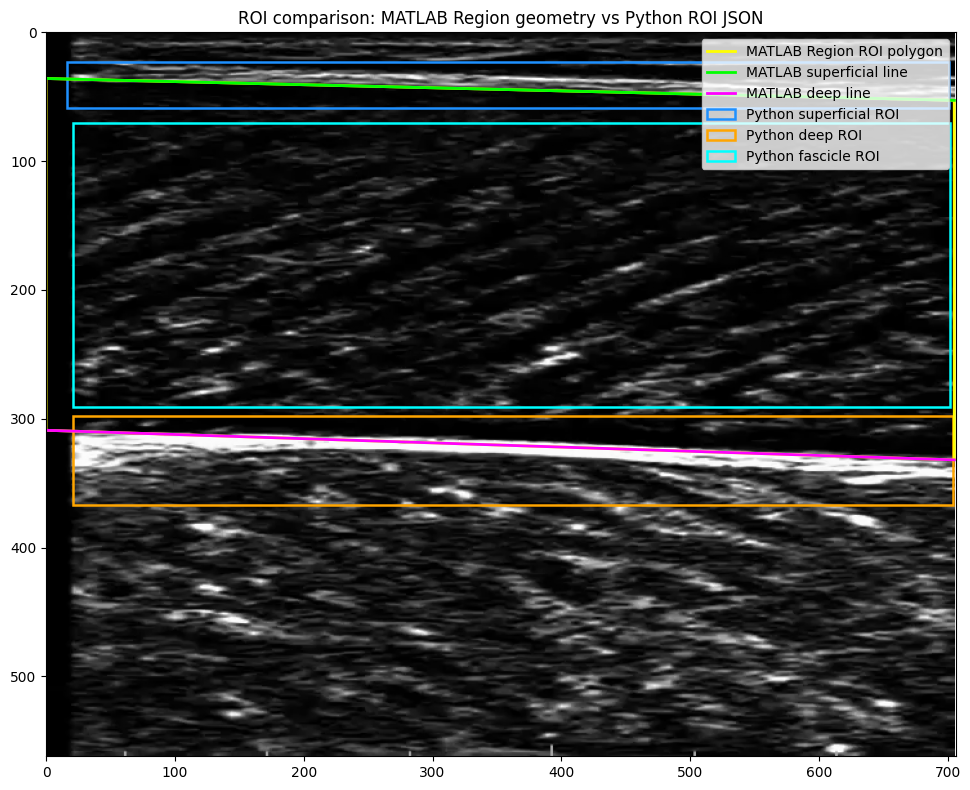

In [9]:
cap = cv2.VideoCapture(str(VIDEO_PATH))
ret, frame_bgr = cap.read()
cap.release()
if not ret:
    raise RuntimeError(f"Could not read first frame from {VIDEO_PATH}")
frame_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(frame_gray, cmap="gray")

mx = matlab_roi["ROIx"] - MATLAB_COORDINATE_BASE
my = matlab_roi["ROIy"] - MATLAB_COORDINATE_BASE
ax.plot(mx, my, color="yellow", linewidth=2.0, label="MATLAB Region ROI polygon")
ax.plot(matlab_roi["sup_x"] - MATLAB_COORDINATE_BASE, matlab_roi["sup_y"] - MATLAB_COORDINATE_BASE, color="lime", linewidth=2.0, label="MATLAB superficial line")
ax.plot(matlab_roi["deep_x"] - MATLAB_COORDINATE_BASE, matlab_roi["deep_y"] - MATLAB_COORDINATE_BASE, color="magenta", linewidth=2.0, label="MATLAB deep line")

colors = {"fascicle": "cyan", "superficial": "dodgerblue", "deep": "orange"}
for name, roi in rois.items():
    x, y, w, h = [float(v) for v in roi]
    ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor=colors.get(name, "white"), linewidth=1.8, label=f"Python {name} ROI"))

ax.set_title("ROI comparison: MATLAB Region geometry vs Python ROI JSON")
ax.set_xlim(0, frame_gray.shape[1])
ax.set_ylim(frame_gray.shape[0], 0)
ax.legend(loc="upper right")
ax.grid(False)
plt.tight_layout()
roi_png = OUT_DIR / "notebook32_roi_overlay.png"
fig.savefig(roi_png, dpi=160)
print("Saved:", roi_png)
plt.show()

## 8. Absolute parity plots

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_absolute_parity_timeseries.png


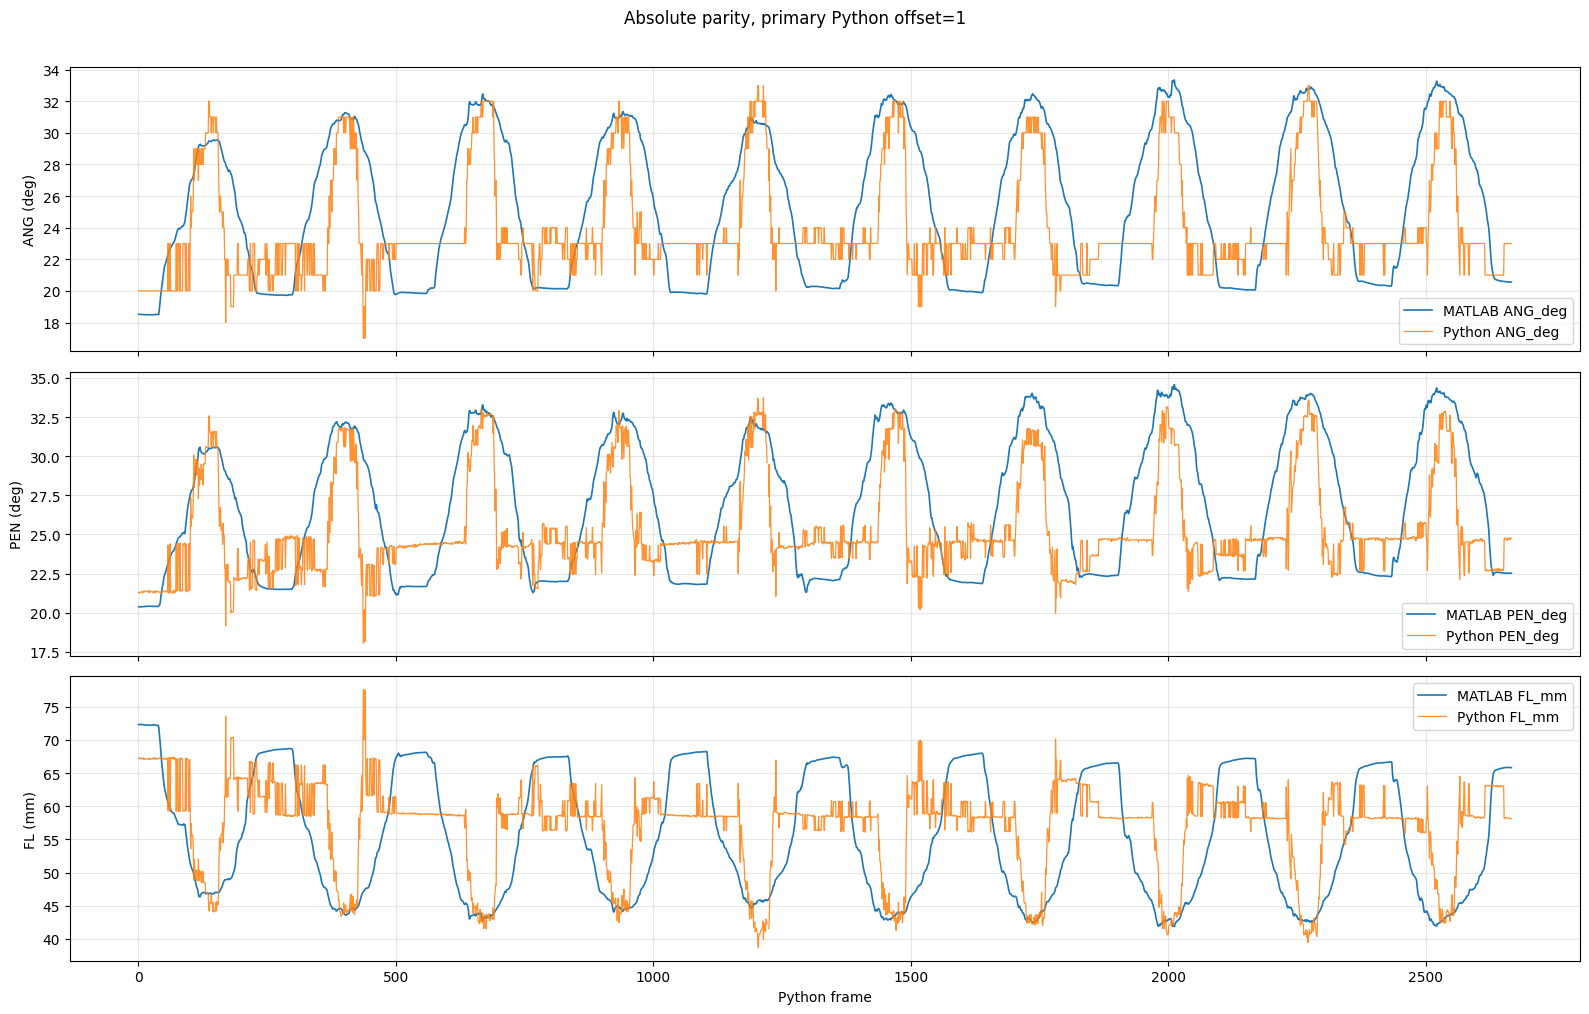

In [10]:
plot_specs = [
    ("ANG_deg", "ANG (deg)"),
    ("PEN_deg", "PEN (deg)"),
    ("FL_mm", "FL (mm)"),
]

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
for ax, (sig, ylabel) in zip(axes, plot_specs):
    ax.plot(aligned["frame"], aligned[f"mat_{sig}"], linewidth=1.2, label=f"MATLAB {sig}")
    ax.plot(aligned["frame"], aligned[f"py_{sig}"], linewidth=0.9, alpha=0.85, label=f"Python {sig}")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
axes[-1].set_xlabel("Python frame")
fig.suptitle(f"Absolute parity, primary Python offset={PRIMARY_PY_OFFSET}", y=1.01)
plt.tight_layout()
absolute_png = OUT_DIR / "notebook32_absolute_parity_timeseries.png"
fig.savefig(absolute_png, dpi=160)
print("Saved:", absolute_png)
plt.show()

## 9. Baseline-normalized parity plots

These plots remove the median baseline offset in the first `BASELINE_SECONDS`. They are useful when the MATLAB and Python ROI are slightly different.

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_baseline_delta_parity_timeseries.png


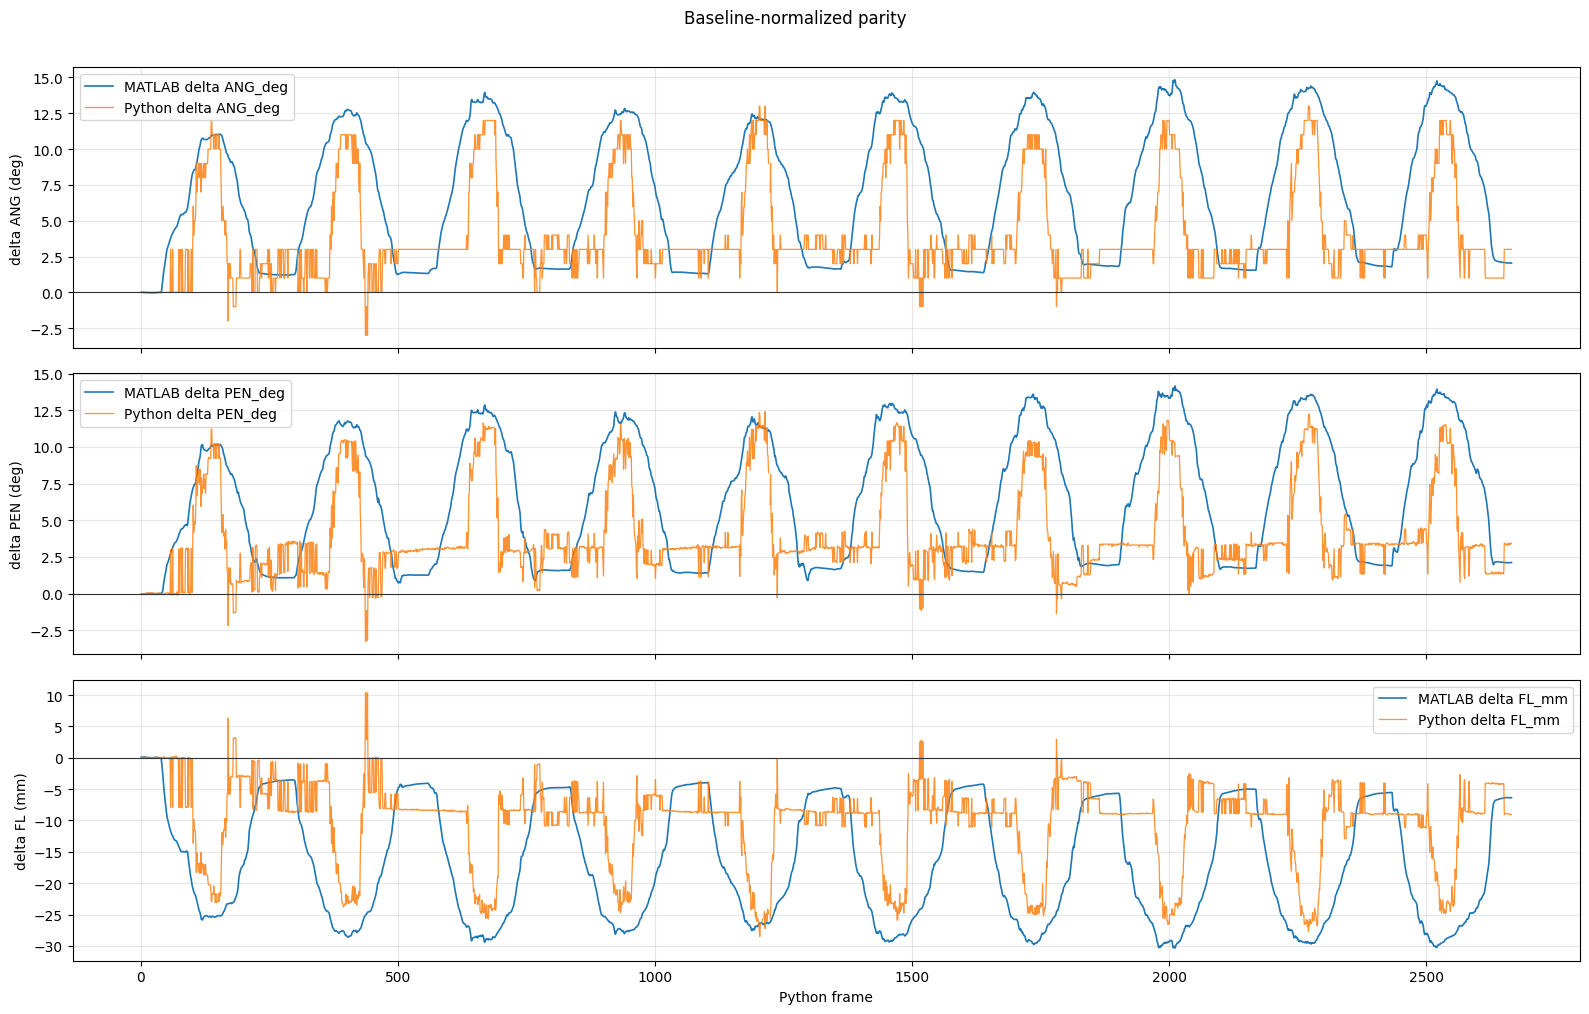

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
for ax, (sig, ylabel) in zip(axes, plot_specs):
    py = aligned[f"py_{sig}"]
    matv = aligned[f"mat_{sig}"]
    py_delta = py - np.nanmedian(py[baseline_mask])
    mat_delta = matv - np.nanmedian(matv[baseline_mask])
    ax.plot(aligned["frame"], mat_delta, linewidth=1.2, label=f"MATLAB delta {sig}")
    ax.plot(aligned["frame"], py_delta, linewidth=0.9, alpha=0.85, label=f"Python delta {sig}")
    ax.axhline(0, color="0.2", linewidth=0.8)
    ax.set_ylabel("delta " + ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
axes[-1].set_xlabel("Python frame")
fig.suptitle("Baseline-normalized parity", y=1.01)
plt.tight_layout()
delta_png = OUT_DIR / "notebook32_baseline_delta_parity_timeseries.png"
fig.savefig(delta_png, dpi=160)
print("Saved:", delta_png)
plt.show()

## 10. Error profiles and scatter parity

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_error_profiles.png


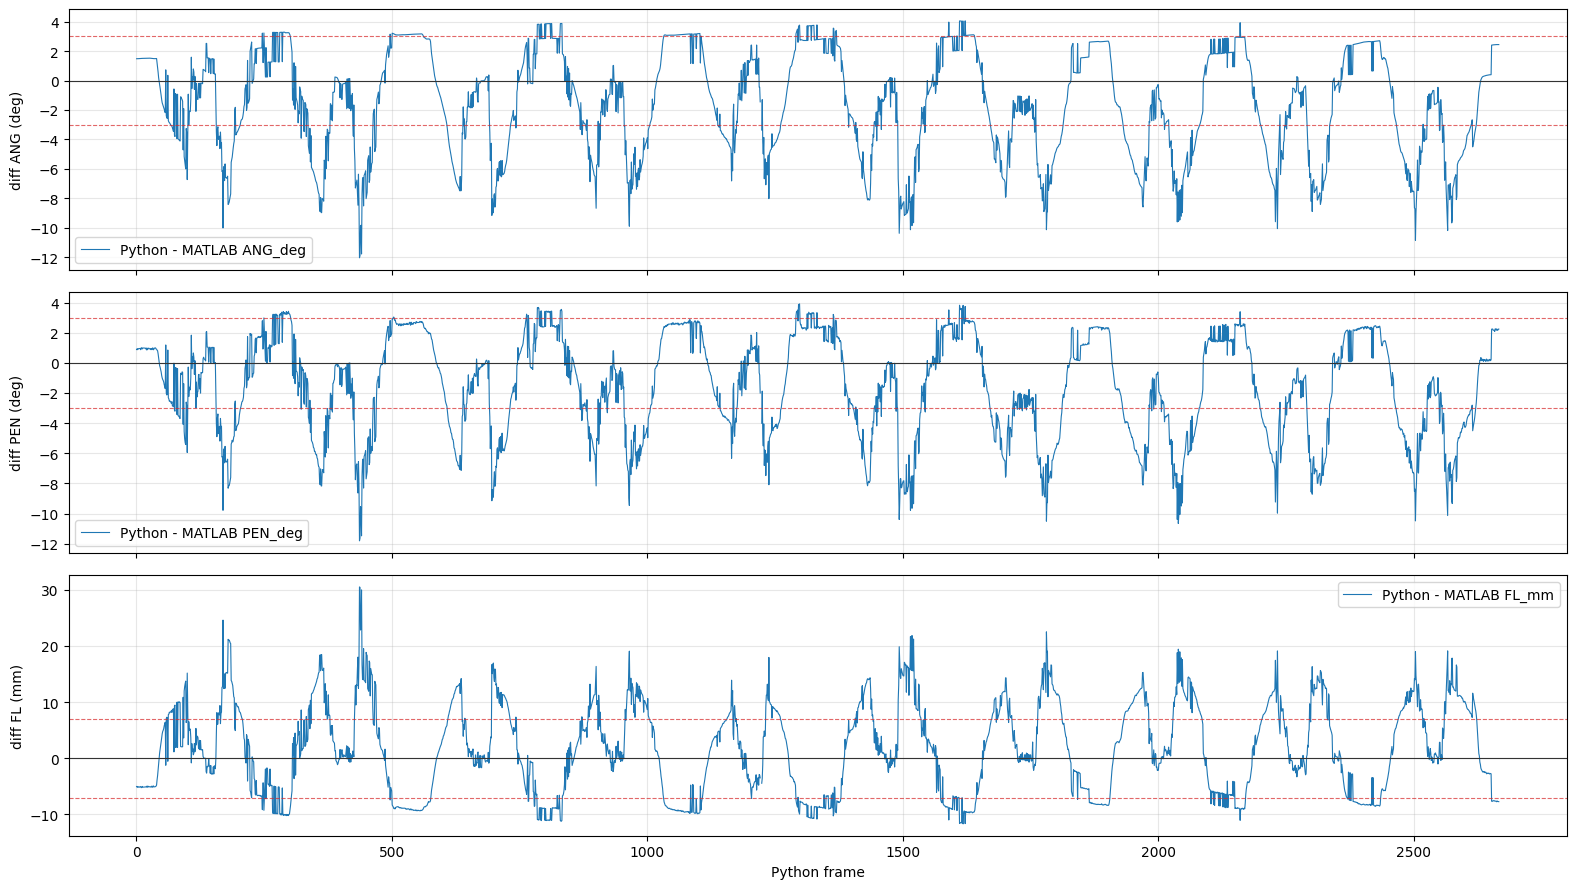

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_scatter_parity.png


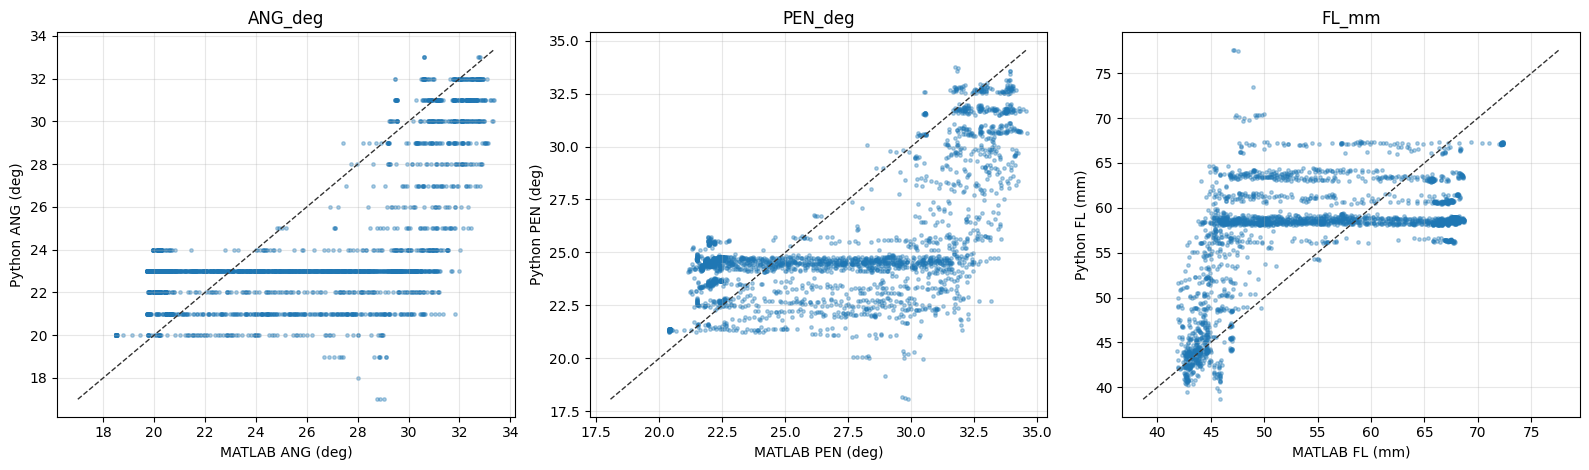

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
for ax, (sig, ylabel) in zip(axes, plot_specs):
    diff = aligned[f"py_{sig}"] - aligned[f"mat_{sig}"]
    ax.plot(aligned["frame"], diff, linewidth=0.8, label=f"Python - MATLAB {sig}")
    ax.axhline(0, color="0.2", linewidth=0.8)
    ax.axhline(WORKING_THRESHOLDS[sig], color="tab:red", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.axhline(-WORKING_THRESHOLDS[sig], color="tab:red", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.set_ylabel("diff " + ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
axes[-1].set_xlabel("Python frame")
plt.tight_layout()
error_png = OUT_DIR / "notebook32_error_profiles.png"
fig.savefig(error_png, dpi=160)
print("Saved:", error_png)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (sig, ylabel) in zip(axes, plot_specs):
    x = aligned[f"mat_{sig}"]
    y = aligned[f"py_{sig}"]
    ax.scatter(x, y, s=6, alpha=0.35)
    finite = np.isfinite(x) & np.isfinite(y)
    lo = float(np.nanmin([np.nanmin(x[finite]), np.nanmin(y[finite])]))
    hi = float(np.nanmax([np.nanmax(x[finite]), np.nanmax(y[finite])]))
    ax.plot([lo, hi], [lo, hi], color="0.2", linewidth=1.0, linestyle="--")
    ax.set_xlabel("MATLAB " + ylabel)
    ax.set_ylabel("Python " + ylabel)
    ax.set_title(sig)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
scatter_png = OUT_DIR / "notebook32_scatter_parity.png"
fig.savefig(scatter_png, dpi=160)
print("Saved:", scatter_png)
plt.show()

## 11. Final gate interpretation

Use this section to decide whether the current Python baseline is ready to freeze before adding speckle or mechanics.

In [13]:
print("Primary alignment")
print("  Python offset:", PRIMARY_PY_OFFSET)
print("  Python start index:", aligned["py_start"])
print("  MATLAB start index:", aligned["mat_start"])
print("  Aligned samples:", aligned["n"])
print()
print("Absolute full-video gate summary")
display(gate_summary)

print("Baseline-normalized full-video metrics")
display(metrics_df[(metrics_df["domain"] == "baseline_delta") & (metrics_df["window"] == "full")][[
    "signal", "n", "bias_median_py_minus_mat", "median_abs_error", "mae", "q95_abs_error", "corr", "working_gate", "strict_gate"
]])

print("Interpretation guide:")
print("- pass under working gate: acceptable for the current ROI-mismatch validation step")
print("- review under strict gate: not a failure, but not exact MATLAB reproduction")
print("- if baseline_delta is much better than absolute, the remaining error is mostly ROI/baseline offset")
print("- if contraction window is worse, inspect frame-level detection errors before adding speckle/mechanics")

Primary alignment
  Python offset: 1
  Python start index: 1
  MATLAB start index: 0
  Aligned samples: 2666

Absolute full-video gate summary


,signal,n,bias_median_py_minus_mat,median_abs_error,mae,q95_abs_error,corr,working_threshold,working_gate,strict_threshold,strict_gate
0,ANG_deg,2664,-1.166522,2.749504,3.119531,7.565046,0.639627,3.0,pass,2.0,review
6,PEN_deg,2664,-1.265419,2.469168,3.002388,7.465412,0.629407,3.0,pass,2.0,review
12,FL_mm,2664,1.234784,6.928372,6.775572,14.215330,0.555634,7.0,pass,5.0,review


Baseline-normalized full-video metrics


,signal,n,bias_median_py_minus_mat,median_abs_error,mae,q95_abs_error,corr,working_gate,strict_gate
1,ANG_deg,2664,-2.651654,2.651654,3.627723,9.050178,0.639627,pass,review
7,PEN_deg,2664,-2.191146,2.393189,3.304812,8.391138,0.629407,pass,review
13,FL_mm,2664,6.258340,6.307056,8.416662,19.238886,0.555634,pass,review


Interpretation guide:
- pass under working gate: acceptable for the current ROI-mismatch validation step
- review under strict gate: not a failure, but not exact MATLAB reproduction
- if baseline_delta is much better than absolute, the remaining error is mostly ROI/baseline offset
- if contraction window is worse, inspect frame-level detection errors before adding speckle/mechanics


## 12. MATLAB-derived ROI JSON and current-pipeline rerun

This section builds one standard Python ROI JSON from the saved MATLAB `Fdat.Region` geometry, then reruns the current command-line pipeline once.

Why this matters:

- the first parity gate used your current manually selected Python ROI
- the MATLAB `.mat` contains the actual tracked superficial/deep lines and full region polygon
- rerunning with a MATLAB-derived ROI tests whether remaining differences are mostly ROI selection or algorithmic

Because `TrackingData.S.Position` and `TrackingData.D.Position` are saved as MATLAB MCOS ROI objects, Python cannot directly decode those `.Position` fields. The derived ROI below uses the decoded `Fdat.Region` geometry instead.

Saved MATLAB-derived ROI JSON: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/Test2_matlab_region_rois.json
{
  "superficial": [
    0,
    15,
    706,
    58
  ],
  "deep": [
    0,
    288,
    706,
    64
  ],
  "fascicle": [
    0,
    67,
    706,
    227
  ]
}
mm_per_pixel_for_rerun = 0.08896797150373459


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_matlab_derived_roi_overlay.png


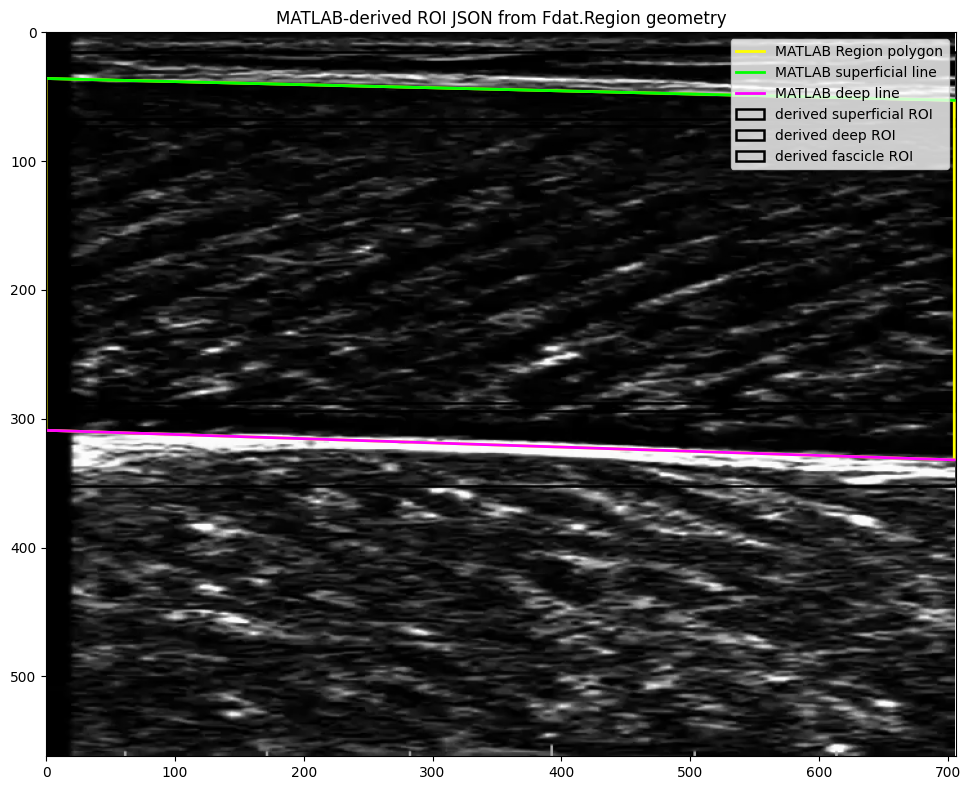

In [14]:
import subprocess

MATLAB_ROI_JSON = PROJECT_ROOT / "data" / "rois" / f"{VIDEO_NAME}_matlab_region_rois.json"
MATLAB_ROI_RUN_DIR = OUT_DIR / "matlab_roi_run"
MATLAB_ROI_RUN_NAME = f"{VIDEO_NAME}_matlab_region_roi"
MATLAB_ROI_RUN_NPZ = MATLAB_ROI_RUN_DIR / f"{MATLAB_ROI_RUN_NAME}_timtrack_final_features_arrays.npz"
MATLAB_ROI_RUN_CSV = MATLAB_ROI_RUN_DIR / f"{MATLAB_ROI_RUN_NAME}_timtrack_final_features.csv"

# Keep future notebook reruns quick. Delete the NPZ or set True to force a rerun.
FORCE_RERUN_MATLAB_ROI_PIPELINE = False


def clamp_rect_from_bounds(x0, y0, x1_exclusive, y1_exclusive, image_shape):
    height, width = image_shape[:2]
    x0 = int(np.floor(x0))
    y0 = int(np.floor(y0))
    x1_exclusive = int(np.ceil(x1_exclusive))
    y1_exclusive = int(np.ceil(y1_exclusive))

    x0 = max(0, min(width - 1, x0))
    y0 = max(0, min(height - 1, y0))
    x1_exclusive = max(x0 + 1, min(width, x1_exclusive))
    y1_exclusive = max(y0 + 1, min(height, y1_exclusive))
    return [int(x0), int(y0), int(x1_exclusive - x0), int(y1_exclusive - y0)]


def derive_roi_json_from_fdat_region(matlab_roi, frame_shape):
    # Convert MATLAB 1-based image coordinates to Python 0-based display/slice coordinates.
    roi_x_py = matlab_roi["ROIx"] - MATLAB_COORDINATE_BASE
    sup_y_py = matlab_roi["sup_y"] - MATLAB_COORDINATE_BASE
    deep_y_py = matlab_roi["deep_y"] - MATLAB_COORDINATE_BASE

    x0 = float(np.nanmin(roi_x_py))
    # MATLAB ROIx=706 means the last pixel index is 705, so the exclusive slice bound is 706.
    x1_exclusive = float(np.nanmax(matlab_roi["ROIx"]))

    # Margins chosen from the decoded MATLAB lines, not the old Python ROI.
    # Aponeurosis ROIs include enough vertical context for the current detector.
    apo_margin_px = 20.0
    fascicle_inner_margin_px = 15.0

    superficial = clamp_rect_from_bounds(
        x0,
        np.nanmin(sup_y_py) - apo_margin_px,
        x1_exclusive,
        np.nanmax(sup_y_py) + apo_margin_px,
        frame_shape,
    )
    deep = clamp_rect_from_bounds(
        x0,
        np.nanmin(deep_y_py) - apo_margin_px,
        x1_exclusive,
        np.nanmax(deep_y_py) + apo_margin_px,
        frame_shape,
    )
    fascicle = clamp_rect_from_bounds(
        x0,
        np.nanmax(sup_y_py) + fascicle_inner_margin_px,
        x1_exclusive,
        np.nanmin(deep_y_py) - fascicle_inner_margin_px,
        frame_shape,
    )
    return {
        "superficial": superficial,
        "deep": deep,
        "fascicle": fascicle,
    }

matlab_region_rois = derive_roi_json_from_fdat_region(matlab_roi, frame_gray.shape)
MATLAB_ROI_JSON.parent.mkdir(parents=True, exist_ok=True)
with MATLAB_ROI_JSON.open("w") as f:
    json.dump(matlab_region_rois, f, indent=4)

print("Saved MATLAB-derived ROI JSON:", MATLAB_ROI_JSON)
print(json.dumps(matlab_region_rois, indent=2))

# Use the same pixel scale as the current Python output so this isolates ROI changes.
if "mm_per_pixel" in py_data.files:
    mm_per_pixel_for_rerun = float(np.asarray(py_data["mm_per_pixel"]).reshape(-1)[0])
else:
    mm_per_pixel_for_rerun = float(np.nanmedian(aligned["py_FL_mm"] / np.asarray(py_data["FL_px"], dtype=float)[aligned["py_start"] : aligned["py_start"] + aligned["n"]]))
print("mm_per_pixel_for_rerun =", mm_per_pixel_for_rerun)

# Visual check of the derived ROI before running.
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(frame_gray, cmap="gray")
ax.plot(matlab_roi["ROIx"] - MATLAB_COORDINATE_BASE, matlab_roi["ROIy"] - MATLAB_COORDINATE_BASE, color="yellow", linewidth=2.0, label="MATLAB Region polygon")
ax.plot(matlab_roi["sup_x"] - MATLAB_COORDINATE_BASE, matlab_roi["sup_y"] - MATLAB_COORDINATE_BASE, color="lime", linewidth=2.0, label="MATLAB superficial line")
ax.plot(matlab_roi["deep_x"] - MATLAB_COORDINATE_BASE, matlab_roi["deep_y"] - MATLAB_COORDINATE_BASE, color="magenta", linewidth=2.0, label="MATLAB deep line")
for name, roi_box in matlab_region_rois.items():
    x, y, w, h = roi_box
    ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=1.8, label=f"derived {name} ROI"))
ax.set_xlim(0, frame_gray.shape[1])
ax.set_ylim(frame_gray.shape[0], 0)
ax.legend(loc="upper right")
ax.set_title("MATLAB-derived ROI JSON from Fdat.Region geometry")
plt.tight_layout()
derived_roi_png = OUT_DIR / "notebook32_matlab_derived_roi_overlay.png"
fig.savefig(derived_roi_png, dpi=160)
print("Saved:", derived_roi_png)
plt.show()

In [15]:
MATLAB_ROI_RUN_DIR.mkdir(parents=True, exist_ok=True)

if FORCE_RERUN_MATLAB_ROI_PIPELINE or not MATLAB_ROI_RUN_NPZ.exists():
    cmd = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "run_new_video.py"),
        str(VIDEO_PATH),
        "--name",
        MATLAB_ROI_RUN_NAME,
        "--roi-path",
        str(MATLAB_ROI_JSON),
        "--results-dir",
        str(MATLAB_ROI_RUN_DIR),
        "--mm-per-pixel",
        str(mm_per_pixel_for_rerun),
        "--save-overlays",
        "5",
        "--progress-every",
        "500",
    ]
    print("Running current pipeline with MATLAB-derived ROI:")
    print(" ".join(cmd))
    completed = subprocess.run(cmd, cwd=PROJECT_ROOT, text=True, capture_output=True, check=True)
    print(completed.stdout)
    if completed.stderr:
        print("STDERR:")
        print(completed.stderr)
else:
    print("Reusing existing MATLAB-derived ROI run:", MATLAB_ROI_RUN_NPZ)

print("Run NPZ exists:", MATLAB_ROI_RUN_NPZ.exists())
print("Run CSV exists:", MATLAB_ROI_RUN_CSV.exists())

Running current pipeline with MATLAB-derived ROI:
/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python /Users/grosbedou/PycharmProjects/NDORMS/scripts/run_new_video.py /Users/grosbedou/PycharmProjects/NDORMS/data/raw/Test2.mp4 --name Test2_matlab_region_roi --roi-path /Users/grosbedou/PycharmProjects/NDORMS/data/rois/Test2_matlab_region_rois.json --results-dir /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/matlab_roi_run --mm-per-pixel 0.08896797150373459 --save-overlays 5 --progress-every 500


Loading ROIs: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/Test2_matlab_region_rois.json
Processed 500/2667 frames - success 500
Processed 1000/2667 frames - success 1000
Processed 1500/2667 frames - success 1500
Processed 2000/2667 frames - success 2000
Processed 2500/2667 frames - success 2500

Done.
Video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/Test2.mp4
Frames processed: 2667
Successful frames: 2667 (100.0%)
CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/matlab_roi_run/Test2_matlab_region_roi_timtrack_final_features.csv
NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/matlab_roi_run/Test2_matlab_region_roi_timtrack_final_features_arrays.npz
ROI: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/Test2_matlab_region_rois.json
Overlay: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/matlab_roi_run/Test2_matlab_region_roi_overlays/Test2_matlab_region_roi_frame_000000.png
Overlay: /Users/grosbedou/PycharmP

## 13. Compare current ROI run vs MATLAB-derived ROI run

This comparison uses the same final-output fields and the same MATLAB target. If the MATLAB-derived ROI improves the gate metrics substantially, ROI selection is a major source of mismatch. If not, the next discrepancies are more likely algorithmic.

In [16]:
matroi_data = np.load(MATLAB_ROI_RUN_NPZ, allow_pickle=True)
python_matroi = {
    "frame": np.asarray(matroi_data["frame"], dtype=int),
    "time_s": np.asarray(matroi_data["time_s"], dtype=float),
    "ANG_deg": np.asarray(matroi_data["ANG_deg"], dtype=float),
    "PEN_deg": np.asarray(matroi_data["PEN_deg"], dtype=float),
    "FL_mm": np.asarray(matroi_data["FL_mm"], dtype=float),
}
print("MATLAB-derived ROI run frames:", len(python_matroi["frame"]))
print("Success rate:", float(np.mean(np.asarray(matroi_data["success"], dtype=bool))))


def align_python_result_with_matlab(py_result, offset):
    if offset >= 0:
        py_start = int(offset)
        mat_start = 0
    else:
        py_start = 0
        mat_start = int(-offset)
    n = min(len(py_result["frame"]) - py_start, len(matlab["ANG_deg"]) - mat_start)
    out = {
        "frame": py_result["frame"][py_start : py_start + n],
        "python_time_s": py_result["time_s"][py_start : py_start + n],
        "matlab_time_s": matlab["Time"][mat_start : mat_start + n],
        "py_start": py_start,
        "mat_start": mat_start,
        "n": n,
    }
    for sig in SIGNALS:
        out[f"py_{sig}"] = py_result[sig][py_start : py_start + n]
        out[f"mat_{sig}"] = matlab[sig][mat_start : mat_start + n]
    return out

matroi_offset_rows = []
for offset in range(-5, 6):
    a = align_python_result_with_matlab(python_matroi, offset)
    row = {"offset": offset, "n": a["n"], "py_start": a["py_start"], "mat_start": a["mat_start"]}
    for sig in SIGNALS:
        row[f"{sig}_median_abs_error"] = med_abs_error(a[f"py_{sig}"], a[f"mat_{sig}"])
    row["combined_display_score"] = row["ANG_deg_median_abs_error"] + row["PEN_deg_median_abs_error"] + row["FL_mm_median_abs_error"] / 3.0
    matroi_offset_rows.append(row)
matroi_offset_df = pd.DataFrame(matroi_offset_rows)
matroi_offset_csv = OUT_DIR / "notebook32_matlab_roi_offset_sensitivity.csv"
matroi_offset_df.to_csv(matroi_offset_csv, index=False)
print("Saved:", matroi_offset_csv)
display(matroi_offset_df)

matroi_aligned = align_python_result_with_matlab(python_matroi, PRIMARY_PY_OFFSET)
print("Primary offset used:", PRIMARY_PY_OFFSET, "n=", matroi_aligned["n"])

matroi_baseline_mask = matroi_aligned["python_time_s"] <= (matroi_aligned["python_time_s"][0] + BASELINE_SECONDS)
if matroi_baseline_mask.sum() < 10:
    matroi_baseline_mask[: min(60, len(matroi_baseline_mask))] = True

matroi_metrics = []
for sig in SIGNALS:
    threshold = WORKING_THRESHOLDS[sig]
    py = matroi_aligned[f"py_{sig}"]
    matv = matroi_aligned[f"mat_{sig}"]
    py_base = np.nanmedian(py[matroi_baseline_mask])
    mat_base = np.nanmedian(matv[matroi_baseline_mask])
    py_delta = py - py_base
    mat_delta = matv - mat_base
    for window_name, mask in {
        "full": np.ones(matroi_aligned["n"], dtype=bool),
        "baseline_first_2s": matroi_baseline_mask,
        "matlab_high_contraction": contraction_mask[: matroi_aligned["n"]],
    }.items():
        matroi_metrics.append(metric_row(sig, py[mask], matv[mask], "absolute", window_name, threshold))
        matroi_metrics.append(metric_row(sig, py_delta[mask], mat_delta[mask], "baseline_delta", window_name, threshold))

matroi_metrics_df = pd.DataFrame(matroi_metrics)
matroi_metrics_csv = OUT_DIR / "notebook32_matlab_roi_parity_metrics.csv"
matroi_metrics_df.to_csv(matroi_metrics_csv, index=False)
print("Saved:", matroi_metrics_csv)

matroi_gate_summary = matroi_metrics_df[(matroi_metrics_df["domain"] == "absolute") & (matroi_metrics_df["window"] == "full")].copy()
matroi_gate_summary = matroi_gate_summary[[
    "signal",
    "n",
    "bias_median_py_minus_mat",
    "median_abs_error",
    "mae",
    "q95_abs_error",
    "corr",
    "working_threshold",
    "working_gate",
    "strict_threshold",
    "strict_gate",
]]
matroi_summary_csv = OUT_DIR / "notebook32_matlab_roi_gate_summary.csv"
matroi_gate_summary.to_csv(matroi_summary_csv, index=False)
print("Saved:", matroi_summary_csv)
display(matroi_gate_summary)

MATLAB-derived ROI run frames: 2667
Success rate: 1.0
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_matlab_roi_offset_sensitivity.csv


,offset,n,py_start,mat_start,ANG_deg_median_abs_error,PEN_deg_median_abs_error,FL_mm_median_abs_error,combined_display_score
0,-5,2661,0,5,2.830175,2.428192,7.063638,7.612913
1,-4,2662,0,4,2.836340,2.423292,7.084162,7.621019
2,-3,2663,0,3,2.841358,2.421081,7.129143,7.638820
3,-2,2664,0,2,2.845383,2.420048,7.154866,7.650386
4,-1,2665,0,1,2.849745,2.421904,7.208827,7.674592
5,0,2666,0,0,2.847467,2.426198,7.236153,7.685717
6,1,2666,1,0,2.847519,2.426509,7.217444,7.679843
7,2,2665,2,0,2.845342,2.429281,7.257230,7.693700
8,3,2664,3,0,2.843084,2.428900,7.243309,7.686421
9,4,2663,4,0,2.841515,2.425658,7.254621,7.685380


Primary offset used: 1 n= 2666
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_matlab_roi_parity_metrics.csv
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_matlab_roi_gate_summary.csv


,signal,n,bias_median_py_minus_mat,median_abs_error,mae,q95_abs_error,corr,working_threshold,working_gate,strict_threshold,strict_gate
0,ANG_deg,2666,-1.166562,2.847519,3.150942,7.446674,0.638880,3.0,pass,2.0,review
6,PEN_deg,2666,-1.353751,2.426509,3.021141,7.296397,0.641929,3.0,pass,2.0,review
12,FL_mm,2666,0.917273,7.217444,6.742733,13.264666,0.553782,7.0,review,5.0,review


In [17]:
current_gate = gate_summary.copy()
current_gate["run"] = "current_manual_python_roi"
matroi_gate = matroi_gate_summary.copy()
matroi_gate["run"] = "matlab_derived_region_roi"
combined_gate = pd.concat([current_gate, matroi_gate], ignore_index=True)
combined_gate = combined_gate[[
    "run",
    "signal",
    "median_abs_error",
    "bias_median_py_minus_mat",
    "mae",
    "q95_abs_error",
    "corr",
    "working_gate",
    "strict_gate",
]]

wide_improvement = current_gate.set_index("signal")[["median_abs_error", "mae", "bias_median_py_minus_mat"]].join(
    matroi_gate.set_index("signal")[["median_abs_error", "mae", "bias_median_py_minus_mat"]],
    lsuffix="_current_roi",
    rsuffix="_matlab_roi",
)
wide_improvement["median_abs_error_change_matlab_roi_minus_current"] = (
    wide_improvement["median_abs_error_matlab_roi"] - wide_improvement["median_abs_error_current_roi"]
)
wide_improvement["mae_change_matlab_roi_minus_current"] = wide_improvement["mae_matlab_roi"] - wide_improvement["mae_current_roi"]

combined_csv = OUT_DIR / "notebook32_current_vs_matlab_roi_gate_summary.csv"
combined_gate.to_csv(combined_csv, index=False)
improvement_csv = OUT_DIR / "notebook32_matlab_roi_improvement_table.csv"
wide_improvement.reset_index().to_csv(improvement_csv, index=False)
print("Saved:", combined_csv)
print("Saved:", improvement_csv)

display(combined_gate)
display(wide_improvement.reset_index())

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_current_vs_matlab_roi_gate_summary.csv
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_matlab_roi_improvement_table.csv


,run,signal,median_abs_error,bias_median_py_minus_mat,mae,q95_abs_error,corr,working_gate,strict_gate
0,current_manual_python_roi,ANG_deg,2.749504,-1.166522,3.119531,7.565046,0.639627,pass,review
1,current_manual_python_roi,PEN_deg,2.469168,-1.265419,3.002388,7.465412,0.629407,pass,review
2,current_manual_python_roi,FL_mm,6.928372,1.234784,6.775572,14.215330,0.555634,pass,review
3,matlab_derived_region_roi,ANG_deg,2.847519,-1.166562,3.150942,7.446674,0.638880,pass,review
4,matlab_derived_region_roi,PEN_deg,2.426509,-1.353751,3.021141,7.296397,0.641929,pass,review
5,matlab_derived_region_roi,FL_mm,7.217444,0.917273,6.742733,13.264666,0.553782,review,review


,signal,median_abs_error_current_roi,mae_current_roi,bias_median_py_minus_mat_current_roi,median_abs_error_matlab_roi,mae_matlab_roi,bias_median_py_minus_mat_matlab_roi,median_abs_error_change_matlab_roi_minus_current,mae_change_matlab_roi_minus_current
0,ANG_deg,2.749504,3.119531,-1.166522,2.847519,3.150942,-1.166562,0.098015,0.031411
1,PEN_deg,2.469168,3.002388,-1.265419,2.426509,3.021141,-1.353751,-0.042659,0.018753
2,FL_mm,6.928372,6.775572,1.234784,7.217444,6.742733,0.917273,0.289072,-0.032839


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_current_vs_matlab_roi_timeseries.png


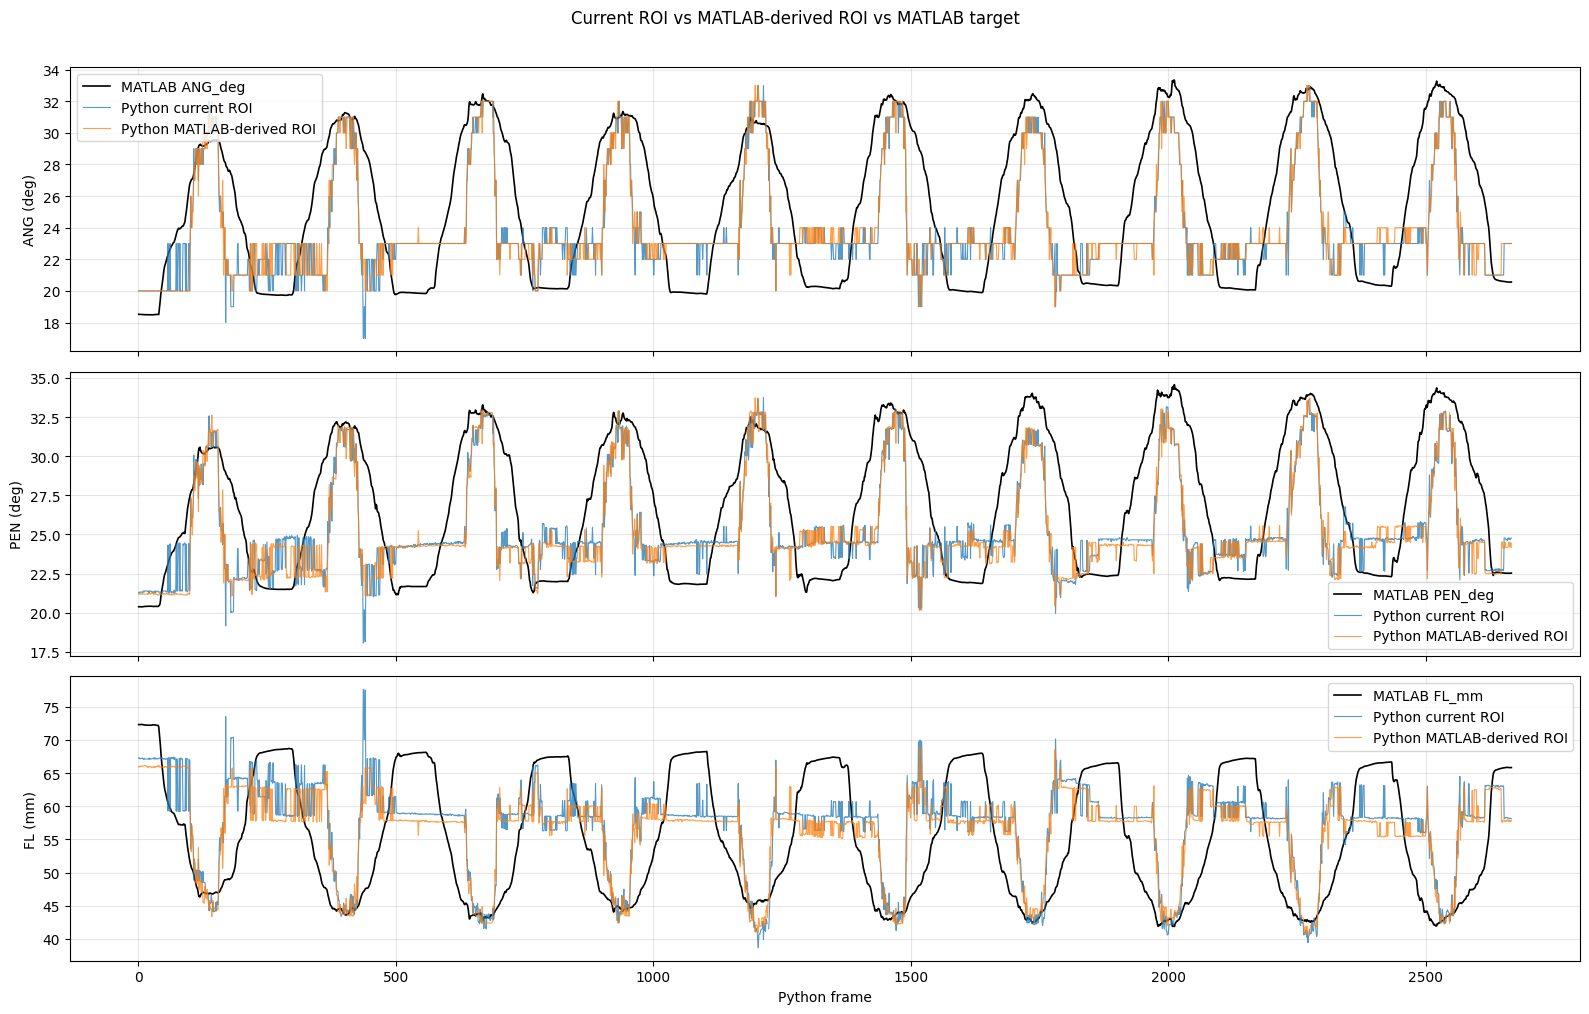

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_parity_gate/notebook32_current_vs_matlab_roi_baseline_delta.png


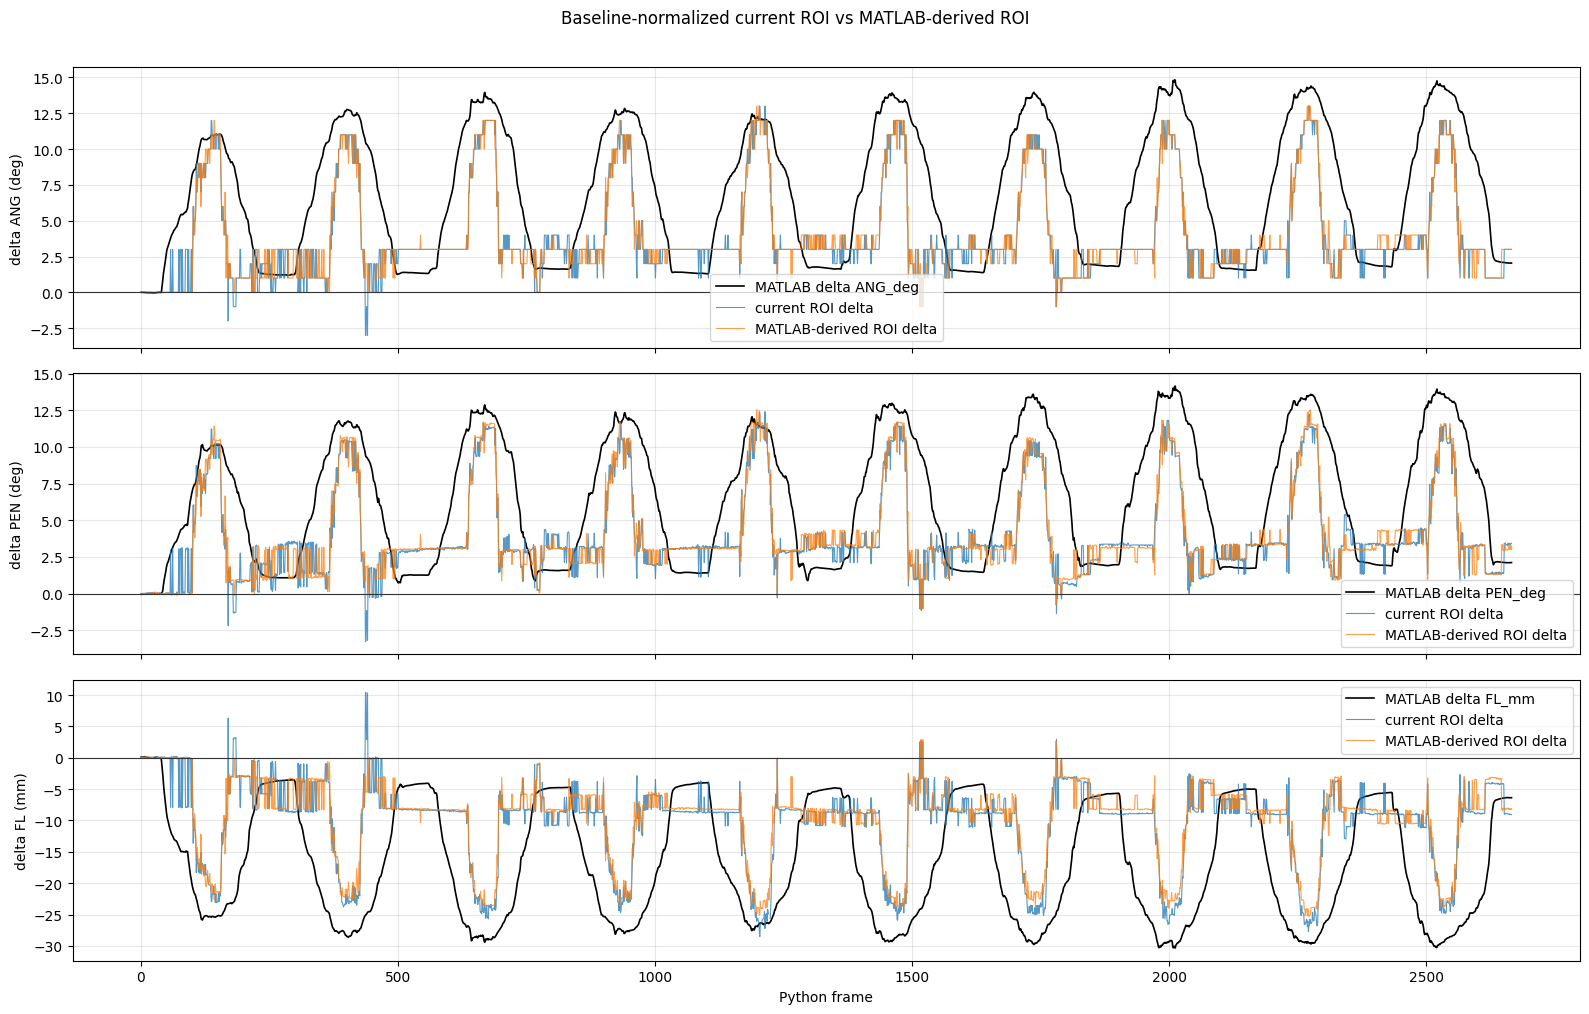

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
for ax, (sig, ylabel) in zip(axes, plot_specs):
    ax.plot(aligned["frame"], aligned[f"mat_{sig}"], linewidth=1.2, color="black", label=f"MATLAB {sig}")
    ax.plot(aligned["frame"], aligned[f"py_{sig}"], linewidth=0.8, alpha=0.75, label="Python current ROI")
    ax.plot(matroi_aligned["frame"], matroi_aligned[f"py_{sig}"], linewidth=0.8, alpha=0.75, label="Python MATLAB-derived ROI")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
axes[-1].set_xlabel("Python frame")
fig.suptitle("Current ROI vs MATLAB-derived ROI vs MATLAB target", y=1.01)
plt.tight_layout()
roi_compare_png = OUT_DIR / "notebook32_current_vs_matlab_roi_timeseries.png"
fig.savefig(roi_compare_png, dpi=160)
print("Saved:", roi_compare_png)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
for ax, (sig, ylabel) in zip(axes, plot_specs):
    current_py = aligned[f"py_{sig}"]
    current_mat = aligned[f"mat_{sig}"]
    matroi_py = matroi_aligned[f"py_{sig}"]
    matroi_mat = matroi_aligned[f"mat_{sig}"]

    current_delta = current_py - np.nanmedian(current_py[baseline_mask])
    mat_delta = current_mat - np.nanmedian(current_mat[baseline_mask])
    matroi_delta = matroi_py - np.nanmedian(matroi_py[matroi_baseline_mask])
    matroi_mat_delta = matroi_mat - np.nanmedian(matroi_mat[matroi_baseline_mask])

    ax.plot(aligned["frame"], mat_delta, linewidth=1.2, color="black", label=f"MATLAB delta {sig}")
    ax.plot(aligned["frame"], current_delta, linewidth=0.8, alpha=0.75, label="current ROI delta")
    ax.plot(matroi_aligned["frame"], matroi_delta, linewidth=0.8, alpha=0.75, label="MATLAB-derived ROI delta")
    ax.axhline(0, color="0.2", linewidth=0.8)
    ax.set_ylabel("delta " + ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
axes[-1].set_xlabel("Python frame")
fig.suptitle("Baseline-normalized current ROI vs MATLAB-derived ROI", y=1.01)
plt.tight_layout()
roi_delta_png = OUT_DIR / "notebook32_current_vs_matlab_roi_baseline_delta.png"
fig.savefig(roi_delta_png, dpi=160)
print("Saved:", roi_delta_png)
plt.show()

## 14. Interpretation of the MATLAB-derived ROI rerun

Use the improvement table above as the answer to the ROI question:

- if the MATLAB-derived ROI improves all three median absolute errors, ROI choice is a major mismatch source
- if angle improves but length worsens, the fascicle ROI/Hough mask is probably sensitive to including the full MATLAB band
- if length improves mostly during contraction, the final formula is likely good but rest geometry differs
- if nothing improves, focus next on algorithmic details: aponeurosis detector, `dohough` mask, Hough peak weighting, and Kalman/output formulas

This section still does not introduce speckle confidence or local mechanics. It is only a baseline parity test.